<a href="https://colab.research.google.com/github/Rashish1/AI-Ml_projects/blob/main/Play_with_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **Initiate and Configure Spark**

---


In [ ]:
!pip3 install pyspark

In [ ]:
from pyspark.sql import SparkSession

# configuring and initializing Spark
spark = SparkSession.builder \
    .appName("Group 9") \
    .master("local[*]") \
    .getOrCreate()

# **Load Unstructured Data**

---


In [ ]:
# locate the log file path
# log_path = "/content/web.log"
log_path = '/content/web.log'

df = spark.read.text(log_path) # initialize the dataframe
df.printSchema() # print dataframe schema
df.show(5) # show top 5 rows

root
 |-- value: string (nullable = true)

+--------------------+
|               value|
+--------------------+
|88.211.105.115 - ...|
|144.6.49.142 - - ...|
|231.70.64.145 - -...|
|219.42.234.172 - ...|
|183.173.185.94 - ...|
+--------------------+
only showing top 5 rows



In [ ]:

# import libraries
from pyspark.sql import SparkSession
from pyspark.sql.functions import regexp_extract, col, count, avg, window, to_timestamp, unix_timestamp
from pyspark.sql.window import Window
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Define log pattern
log_pattern = r'(\d+\.\d+\.\d+\.\d+) - - \[(.*?)\] "(.*?) (.*?) HTTP/(\d+\.\d+)" (\d+) (\d+) (.*)'

logs_df = raw_logs.select()

print(raw_logs)
# Create a DataFrame with schema from the log data
logs_df = raw_logs.select(
    regexp_extract(col("value"), log_pattern, 1).alias("ip"),
    regexp_extract(col("value"), log_pattern, 2).alias("timestamp"),
    regexp_extract(col("value"), log_pattern, 3).alias("http_method"),
    regexp_extract(col("value"), log_pattern, 4).alias("url"),
    regexp_extract(col("value"), log_pattern, 5).alias("protocol_version"),
    regexp_extract(col("value"), log_pattern, 6).alias("status_code").cast("int"),
    regexp_extract(col("value"), log_pattern, 7).alias("response_size").cast("int"),
    regexp_extract(col("value"), log_pattern, 8).alias("message")
)

# Filter out malformed entries
logs_df = logs_df.filter(col("ip").isNotNull() & col("timestamp").isNotNull())

display(logs_df)
x = logs_df.limit(5)

df = x.toPandas()
data_table.DataTable(df)


DataFrame[value: string]


DataFrame[ip: string, timestamp: string, http_method: string, url: string, protocol_version: string, status_code: int, response_size: int, message: string]

NameError: name 'data_table' is not defined

In [ ]:
# Convert timestamp to proper format for caluculations
logs_df = logs_df.withColumn("parsed_timestamp", to_timestamp("timestamp", "dd/MMM/yyyy:HH:mm:ss"))

# window specification to calculate rolling hourly traffic
window_spec = Window.partitionBy("ip").orderBy(unix_timestamp("parsed_timestamp")).rangeBetween(-3600, 0)

# Calculate rolling hourly traffic per IP
rolling_traffic = logs_df.withColumn("hourly_traffic", count("url").over(window_spec))

# Show the results
rt = rolling_traffic.select("ip", "timestamp", "hourly_traffic")
rt.show(10)

+-------------+--------------------+--------------+
|           ip|           timestamp|hourly_traffic|
+-------------+--------------------+--------------+
|  1.1.224.117|06/Apr/2022:21:31:49|             1|
|  1.1.240.113|01/Dec/2022:21:21:16|             1|
|    1.1.51.64|08/Dec/2022:12:35:45|             1|
| 1.10.218.215|19/May/2022:18:39:46|             1|
| 1.10.231.152|10/Aug/2022:18:06:24|             1|
| 1.100.117.88|07/Aug/2023:03:23:25|             1|
|1.100.156.207|17/May/2022:20:06:00|             1|
|1.101.116.248|23/Apr/2023:01:14:26|             1|
| 1.101.125.30|14/Jun/2023:18:37:30|             1|
| 1.101.237.77|28/Oct/2023:16:16:27|             1|
+-------------+--------------------+--------------+
only showing top 10 rows



In [ ]:
from pyspark.sql.functions import date_format, avg, countDistinct

# Extract date from timestamp
logs_df = logs_df.withColumn("date", date_format("parsed_timestamp", "yyyy-MM-dd"))

# Group by date and calculate unique visitors and average response size
daily_aggregation = logs_df.groupBy("date") \
    .agg(
        countDistinct("ip").alias("unique_visitors"),
        avg("response_size").alias("avg_response_size")
    )

# Show the results
result = daily_aggregation.limit(10).toPandas()
result.head()

,date,unique_visitors,avg_response_size
0,2023-05-18,2987,51080.293940
1,2022-10-05,2871,50545.075235
2,2023-01-21,2994,50239.862057
3,2023-05-01,2881,50612.637973
4,2023-04-28,2952,49539.551829


In [ ]:
from pyspark.sql.functions import sum

# Group by URL and calculate total response size
top_urls = logs_df.groupBy("url") \
    .agg(
        sum("response_size").alias("total_response_size")
    ) \
    .orderBy(col("total_response_size").desc()) \
    .limit(5)

# Show the results
result = top_urls.limit(10).toPandas()
result.head()

,url,total_response_size
0,/security/aws-certification/,860968703
1,/web-development/missions/,859838977
2,/shuttle/firewall/,856797875
3,/security/technology/,856657235
4,/networking/frontend-frameworks-comparison/,854397149


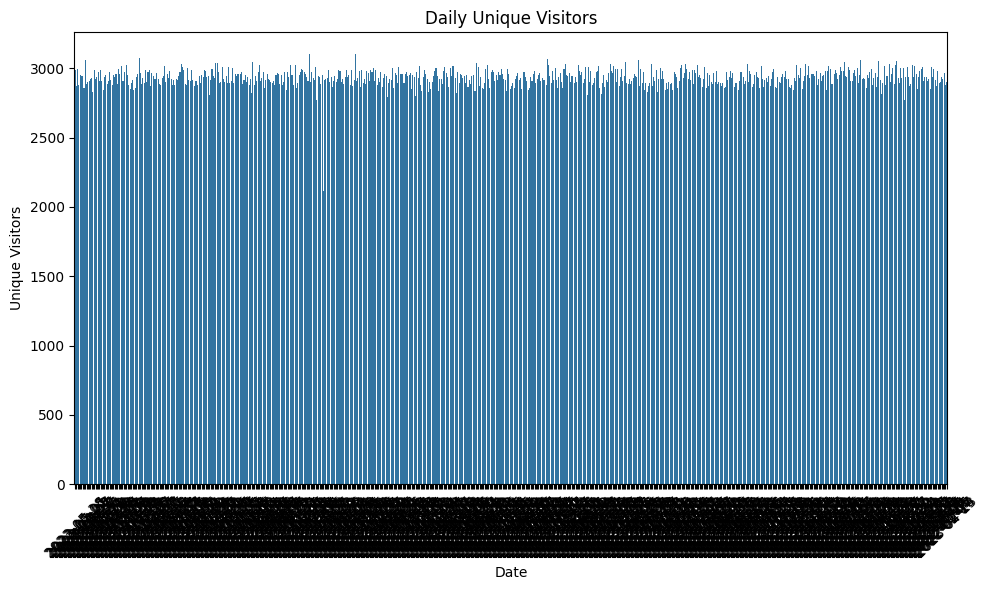

In [ ]:
# Convert daily aggregation DataFrame to Pandas
daily_agg_pd = daily_aggregation.toPandas()

# Plot daily unique visitors
plt.figure(figsize=(10, 6))
sns.barplot(x="date", y="unique_visitors", data=daily_agg_pd)
plt.title("Daily Unique Visitors")
plt.xticks(rotation=45)
plt.xlabel("Date")
plt.ylabel("Unique Visitors")
plt.tight_layout()
plt.show()

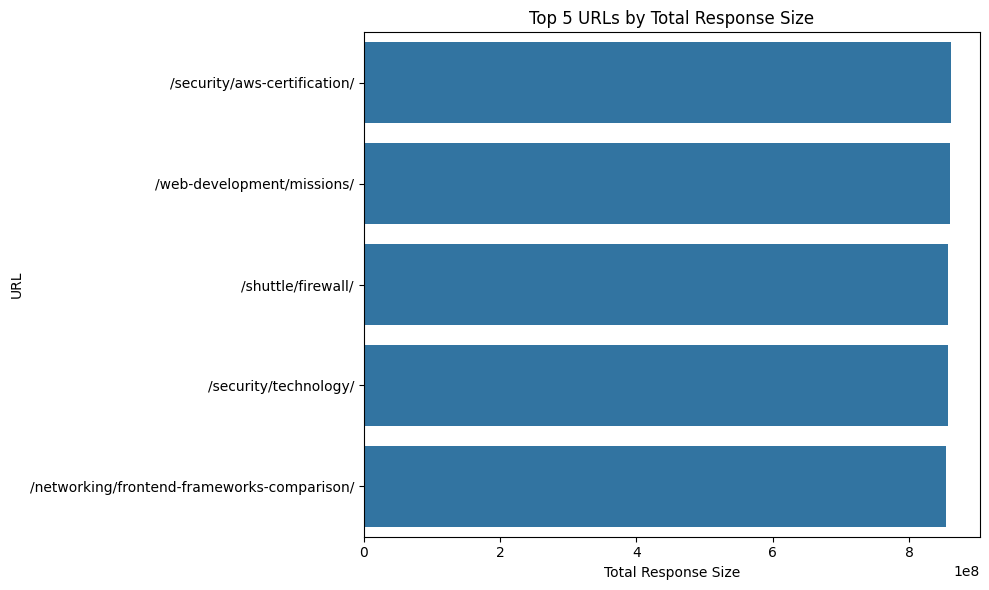

In [ ]:
# Convert top URLs DataFrame to Pandas
top_urls_pd = top_urls.toPandas()

# Plot top 5 URLs
plt.figure(figsize=(10, 6))
sns.barplot(x="total_response_size", y="url", data=top_urls_pd)
plt.title("Top 5 URLs by Total Response Size")
plt.xlabel("Total Response Size")
plt.ylabel("URL")
plt.tight_layout()
plt.show()

In [ ]:

#Required modules

from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, TimestampType
from pyspark.sql.functions import regexp_extract, col, to_timestamp

# DEFINING THE SCHEMA
schema = StructType([
    StructField("ip", StringType(), True),
    StructField("timestamp", StringType(), True),
    StructField("method", StringType(), True),
    StructField("resource", StringType(), True),
    StructField("protocol", StringType(), True),
    StructField("status", IntegerType(), True),
    StructField("size", IntegerType(), True),
    StructField("message", StringType(), True)
])

In [ ]:
#LOADING DATA FILE

raw_df = df

raw_df.show()

+--------------------+
|               value|
+--------------------+
|88.211.105.115 - ...|
|144.6.49.142 - - ...|
|231.70.64.145 - -...|
|219.42.234.172 - ...|
|183.173.185.94 - ...|
|164.12.8.113 - - ...|
|110.98.7.240 - - ...|
|27.182.196.243 - ...|
|123.31.25.147 - -...|
|220.182.78.75 - -...|
|206.186.128.82 - ...|
|143.238.50.180 - ...|
|12.33.251.59 - - ...|
|39.107.109.242 - ...|
|250.231.144.68 - ...|
|103.105.160.60 - ...|
|246.167.148.159 -...|
|185.221.50.185 - ...|
|144.143.171.58 - ...|
|131.119.14.93 - -...|
+--------------------+
only showing top 20 rows



In [ ]:
# DEFINING REGULAR EXPRESSIONS(REGEX) FOR INDIVIDUAL FIELDS TO BE PARSED
regex_patterns = {
    # IP Address
    "ip": r"^(\d+\.\d+\.\d+\.\d+)",
    # Timestamp
    "timestamp": r"\[(.*?)\]",
    # HTTP Method
    "method": r"\"([A-Z]+)",
    # Resource
    "resource": r"\"[A-Z]+ ([^\s]+)",
    # Protocol
    "protocol": r" ([A-Z]+/\d+\.\d+)\"",
    # Status Code
    "status": r"\" \d+ (\d{3})",
    # Response Size
    "size": r"(\d+)(?= [A-Za-z])",
    # Message
    "message": r"[A-Za-z].+$"
}

# EXTRACTING FIELDS USING REGEX
parsed_df = raw_df.select(
    regexp_extract(col("value"), regex_patterns["ip"], 1).alias("ip"),
    regexp_extract(col("value"), regex_patterns["timestamp"], 1).alias("timestamp"),
    regexp_extract(col("value"), regex_patterns["method"], 1).alias("method"),
    regexp_extract(col("value"), regex_patterns["resource"], 1).alias("resource"),
    regexp_extract(col("value"), regex_patterns["protocol"], 1).alias("protocol"),
    regexp_extract(col("value"), regex_patterns["status"], 1).cast("int").alias("status"),
    regexp_extract(col("value"), regex_patterns["size"], 1).cast("int").alias("size"),
    regexp_extract(col("value"), regex_patterns["message"], 0).alias("message")
)

# CONVERTING TIMESTAMP TO TIMESTAMP TYPE
parsed_df = parsed_df.withColumn("timestamp", to_timestamp("timestamp", "dd/MMM/yyyy:HH:mm:ss"))

# SHOW THE PARSED DATAFRAME
parsed_df.show(truncate=False)

+---------------+-------------------+------+---------------------------------------+---------+------+-----+-------------------------------------------------------------------------------------------------------------------------------------+
|ip             |timestamp          |method|resource                               |protocol |status|size |message                                                                                                                              |
+---------------+-------------------+------+---------------------------------------+---------+------+-----+-------------------------------------------------------------------------------------------------------------------------------------+
|88.211.105.115 |2022-03-04 14:17:48|POST  |/history/missions/                     |HTTP/2.0 |124   |12456|Mar/2022:14:17:48] "POST /history/missions/ HTTP/2.0" 414 12456 Caution: System may require attention. Check logs for details.       |
|144.6.49.142   |2022-09-02 15:1

In [ ]:
(parsed_df.printSchema())

root
 |-- ip: string (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- method: string (nullable = true)
 |-- resource: string (nullable = true)
 |-- protocol: string (nullable = true)
 |-- status: integer (nullable = true)
 |-- size: integer (nullable = true)
 |-- message: string (nullable = true)



In [ ]:
# CREATING A TEMPORARY VIEW FOR THE PARSED DF

from pyspark.sql.window import Window
from pyspark.sql.functions import col, row_number, date_format
from pyspark.sql.functions import window, count


parsed_df.createOrReplaceTempView("weblogs")

In [ ]:
# SQL QUERY TO CALCULATE UNIQUE VISITORS(PER DAY) USING WINDOW FUNCTION (QUERY 1)
unique_visitors_query = """
SELECT
    date,
    unique_visitors
FROM (
    SELECT
        date,
        ip,
        ROW_NUMBER() OVER (PARTITION BY date, ip ORDER BY timestamp) AS row_num,
        COUNT(*) OVER (PARTITION BY date) AS unique_visitors
    FROM (
        SELECT
            ip,
            DATE_FORMAT(timestamp, 'yyyy-MM-dd') AS date,
            timestamp
        FROM weblogs
    ) temp_table
) ranked_visitors
WHERE row_num = 1
ORDER BY date
"""

# Execute the SQL query
unique_visitors_result = spark.sql(unique_visitors_query)
unique_visitors_result.show()

+----------+---------------+
|      date|unique_visitors|
+----------+---------------+
|2022-01-01|            413|
|2022-01-01|            413|
|2022-01-01|            413|
|2022-01-01|            413|
|2022-01-01|            413|
|2022-01-01|            413|
|2022-01-01|            413|
|2022-01-01|            413|
|2022-01-01|            413|
|2022-01-01|            413|
|2022-01-01|            413|
|2022-01-01|            413|
|2022-01-01|            413|
|2022-01-01|            413|
|2022-01-01|            413|
|2022-01-01|            413|
|2022-01-01|            413|
|2022-01-01|            413|
|2022-01-01|            413|
|2022-01-01|            413|
+----------+---------------+
only showing top 20 rows



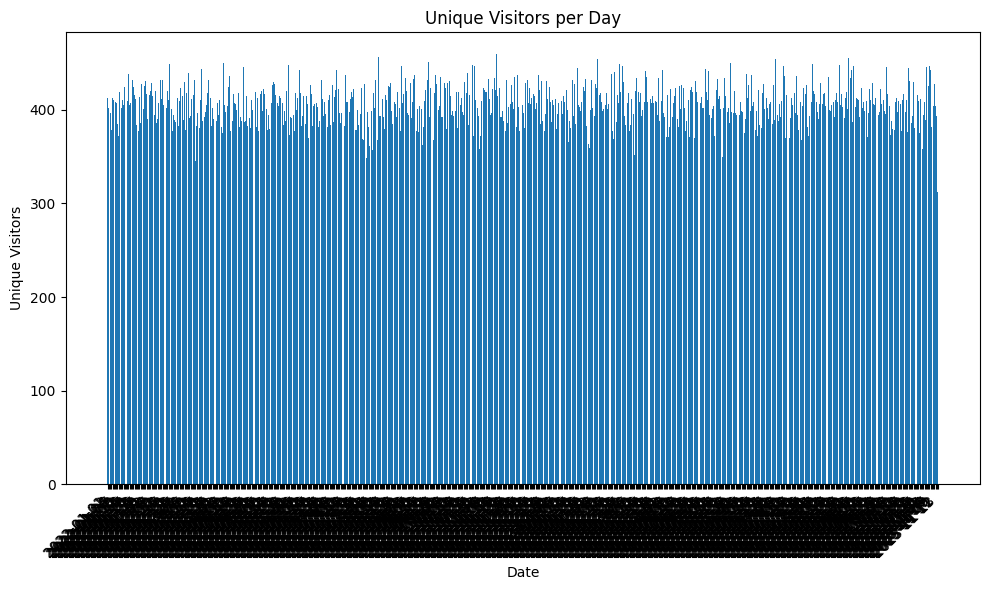

In [ ]:
# VISUALIZATION FOR UNIQUE VISITORS

import matplotlib.pyplot as plt

# CONVERTING TO PANDAS DF
unique_visitors_pd = unique_visitors_result.toPandas()

# BAR CHART
plt.figure(figsize=(10, 6))
plt.bar(unique_visitors_pd['date'], unique_visitors_pd['unique_visitors'])
plt.xlabel('Date')
plt.ylabel('Unique Visitors')
plt.title('Unique Visitors per Day')
plt.xticks(rotation=45, ha='right')  # TO AVOID OVERLAPPING LABELS
plt.tight_layout()  # TO PREVENT LAYOUT FROM OVERLAPPING
plt.show()

In [ ]:
# ROLLING HOURLY TRAFFIC TREND (QUERY 2) (COUNT OF IP ADDRESSES OVER A ROLLING HOURLY WINDOW)

hourly_traffic_query = """
SELECT
log_hour,
COUNT(ip) OVER (
    PARTITION BY log_hour
    ORDER BY log_hour ROWS BETWEEN 1 PRECEDING AND CURRENT ROW
) AS hourly_traffic_trend
FROM (
    SELECT
        ip,
        DATE_FORMAT(timestamp, 'yyyy-MM-dd HH') AS log_hour
    FROM weblogs
) AS hourly_logs
ORDER BY log_hour
"""
hourly_traffic_df = spark.sql(hourly_traffic_query)
hourly_traffic_df.show()

+-------------+--------------------+
|     log_hour|hourly_traffic_trend|
+-------------+--------------------+
|2022-01-01 00|                   1|
|2022-01-01 00|                   2|
|2022-01-01 00|                   2|
|2022-01-01 00|                   2|
|2022-01-01 00|                   2|
|2022-01-01 00|                   2|
|2022-01-01 00|                   2|
|2022-01-01 00|                   2|
|2022-01-01 00|                   2|
|2022-01-01 00|                   2|
|2022-01-01 00|                   2|
|2022-01-01 00|                   2|
|2022-01-01 00|                   2|
|2022-01-01 00|                   2|
|2022-01-01 00|                   2|
|2022-01-01 01|                   1|
|2022-01-01 01|                   2|
|2022-01-01 01|                   2|
|2022-01-01 01|                   2|
|2022-01-01 01|                   2|
+-------------+--------------------+
only showing top 20 rows



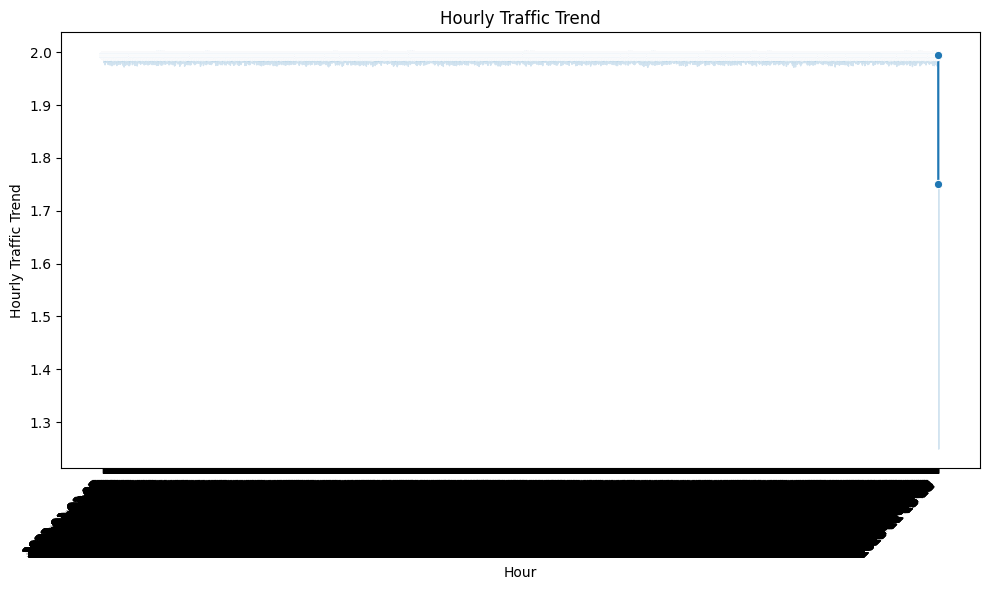

In [ ]:
# VISUALIZATION FOR ROLLING HOURLY TRAFFIC

import seaborn as sns
import matplotlib.pyplot as plt


# CONVERTING TO PANDAS DF
hourly_traffic_pd = hourly_traffic_df.toPandas()

# LINE CHART
plt.figure(figsize=(10, 6))
sns.lineplot(x='log_hour', y='hourly_traffic_trend', data=hourly_traffic_pd, marker='o')
plt.title('Hourly Traffic Trend')
plt.xlabel('Hour')
plt.ylabel('Hourly Traffic Trend')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:

#regular expression code based on the log pattern to extract the data
from pyspark.sql.functions import regexp_extract, to_timestamp
regex_pattern = r'^([^\ ]*) - - \[([^\]]*)\] "([A-Z]+) ([^\ ]*) ([^\ ]*)" (\d+) (\d+) (.*)$'

#creating data frame
new_df = df.select(
    regexp_extract('value', regex_pattern, 1).alias('ip'),
    to_timestamp(regexp_extract('value', regex_pattern, 2),'dd/MMM/yyy:HH:mm:ss').alias('date'),
    regexp_extract('value', regex_pattern, 3).alias('method'),
    regexp_extract('value', regex_pattern, 4).alias('url'),
    regexp_extract('value', regex_pattern, 5).alias('http_version'),
    regexp_extract('value', regex_pattern, 6).alias('status_code'),
    regexp_extract('value', regex_pattern, 7).alias('bytes'),
    regexp_extract('value', regex_pattern, 8).alias('message')
)

# Show the parsed data for inspection
new_df.show()

+---------------+-------------------+------+--------------------+------------+-----------+-----+--------------------+
|             ip|               date|method|                 url|http_version|status_code|bytes|             message|
+---------------+-------------------+------+--------------------+------------+-----------+-----+--------------------+
| 88.211.105.115|2022-03-04 14:17:48|  POST|  /history/missions/|    HTTP/2.0|        414|12456|Caution: System m...|
|   144.6.49.142|2022-09-02 15:16:00|  POST| /security/firewall/|   HTTPS/1.0|        203|97126|Warning: Unusual ...|
|  231.70.64.145|2022-07-19 01:31:31|   PUT|/web-development/...|    HTTP/1.0|        201|33093|Informational mes...|
| 219.42.234.172|2022-02-08 11:34:57|  POST|/networking/techn...|    HTTP/1.0|        415|68827|Debug: Detailed s...|
| 183.173.185.94|2023-08-29 03:07:11|   GET| /security/firewall/|    HTTP/2.0|        205|30374|Warning: Unusual ...|
|   164.12.8.113|2023-05-22 09:48:25|   GET|/web-develop

In [ ]:
new_df.createOrReplaceTempView('weblogview')

In [ ]:
#2a sql with window function
#detecting traffic spikes with rolling hourly requests
sqldf = spark.sql('''
SELECT
    hour(date) AS hour,
    COUNT(*) AS requests,
    SUM(COUNT(*)) OVER (ORDER BY hour(date) ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) AS rolling_hourly_requests
FROM weblogview
GROUP BY hour(date)
ORDER BY hour LIMIT 10
''')
sqldf.show()

24/12/15 17:00:27 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
24/12/15 17:00:27 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
24/12/15 17:00:27 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


+----+--------+-----------------------+
|hour|requests|rolling_hourly_requests|
+----+--------+-----------------------+
|   0|  125373|                 125373|
|   1|  124493|                 249866|
|   2|  125392|                 375258|
|   3|  124947|                 500205|
|   4|  125239|                 625444|
|   5|  125049|                 750493|
|   6|  125200|                 875693|
|   7|  124930|                1000623|
|   8|  124976|                1125599|
|   9|  125056|                1250655|
+----+--------+-----------------------+



24/12/15 17:00:35 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
24/12/15 17:00:35 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
24/12/15 17:00:35 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
24/12/15 17:00:35 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


24/12/15 17:00:35 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
24/12/15 17:00:35 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
24/12/15 17:00:35 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
24/12/15 17:00:42 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
24/12/15 17:00:42 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
24/12/15 17:00:42 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
24/12/15 1

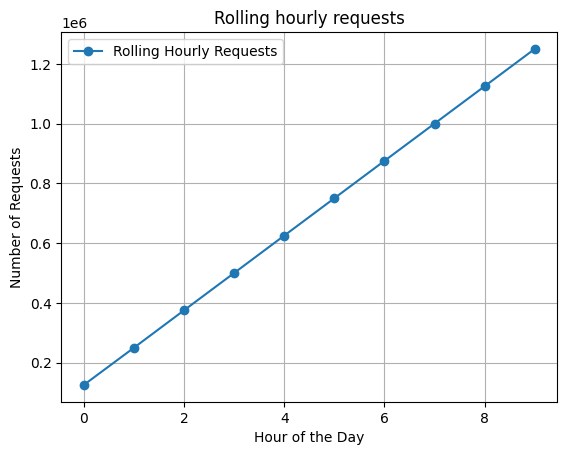

In [ ]:
pandas_df=sqldf.toPandas()

#plotting the data
plt.plot(pandas_df['hour'], pandas_df['rolling_hourly_requests'], marker='o', label='Rolling Hourly Requests')

#label
plt.title('Rolling hourly requests')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Requests')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

In [ ]:
#2b complex aggregation: Traffic patterns with daily unique visitors
sqldf=spark.sql('''
SELECT
  date_format(date,'yyyy-MM-dd') As Day,
  COUNT(DISTINCT ip) AS unique_visitors,
  COUNT(*) AS total_requests
FROM weblogview
GROUP BY date_format(date,'yyyy-MM-dd')
ORDER BY Day
''')
sqldf.show()

24/12/15 17:00:57 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
24/12/15 17:00:57 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
24/12/15 17:00:57 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
24/12/15 17:00:57 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
24/12/15 17:00:57 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
24/12/15 17:00:57 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
24/12/15 17:00:57 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
24/12/15 17:00:57 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
24/12/15 17:01:05 WARN RowBasedKeyValueBatch: Calling spill() on

+----------+---------------+--------------+
|       Day|unique_visitors|total_requests|
+----------+---------------+--------------+
|2022-01-01|           4533|          4533|
|2022-01-02|           4351|          4351|
|2022-01-03|           4331|          4331|
|2022-01-04|           4383|          4383|
|2022-01-05|           4464|          4464|
|2022-01-06|           4418|          4418|
|2022-01-07|           4384|          4384|
|2022-01-08|           4298|          4298|
|2022-01-09|           4365|          4365|
|2022-01-10|           4394|          4395|
|2022-01-11|           4405|          4405|
|2022-01-12|           4365|          4365|
|2022-01-13|           4345|          4345|
|2022-01-14|           4385|          4385|
|2022-01-15|           4400|          4400|
|2022-01-16|           4412|          4412|
|2022-01-17|           4344|          4344|
|2022-01-18|           4511|          4511|
|2022-01-19|           4357|          4357|
|2022-01-20|           4393|    

24/12/15 17:01:15 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
24/12/15 17:01:15 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
24/12/15 17:01:16 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
24/12/15 17:01:16 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
24/12/15 17:01:16 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
24/12/15 17:01:16 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
24/12/15 17:01:16 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
24/12/15 17:01:16 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
24/12/15 17:01:23 WARN RowBasedKeyValueBatch: Calling spill() on

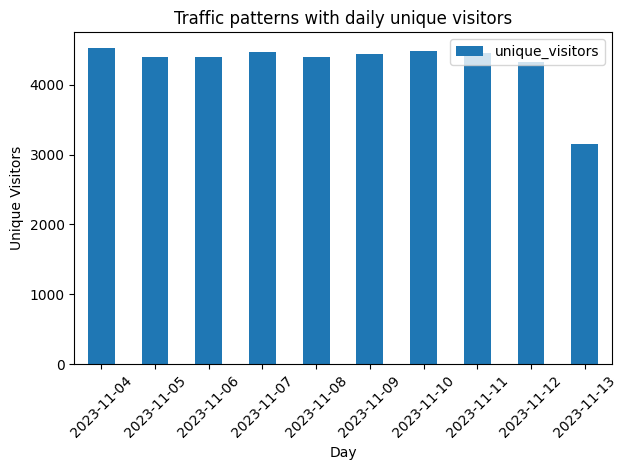

In [ ]:
# Convert Spark DataFrame to Pandas DataFrame
pandas_df = sqldf.toPandas()

#shwoing the most recent 10 days since the data is too huge to show in graph
pandas_df_limit=pandas_df.tail(10)


pandas_df_limit.plot(x='Day',y='unique_visitors',kind='bar')
plt.title('Traffic patterns with daily unique visitors')
plt.xlabel('Day')
plt.ylabel('Unique Visitors')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:

# DF Creation with REGEX

#  regex pattern to extract features from log data
log_pattern = r'(\d+\.\d+\.\d+\.\d+) - - \[(.*?)\] "(.*?) (.*?) (.*?)" (\d{3}) (\d+) (.*)'

# extracting 3 features for querying
df = df.select(
    regexp_extract('value', log_pattern, 2).alias('timestamp'),
    regexp_extract('value', log_pattern, 3).alias('http_method').cast("string"),
    regexp_extract('value', log_pattern, 7).alias('response_size').cast("integer"),
)

# converting string date to time stamp for querying purpose
df = df.withColumn('timestamp', to_timestamp('timestamp', 'dd/MMM/yyyy:HH:mm:ss'))

df.printSchema()
df.show(5)

root
 |-- timestamp: timestamp (nullable = true)
 |-- http_method: string (nullable = true)
 |-- response_size: integer (nullable = true)

+-------------------+-----------+-------------+
|          timestamp|http_method|response_size|
+-------------------+-----------+-------------+
|2022-03-04 14:17:48|       POST|        12456|
|2022-09-02 15:16:00|       POST|        97126|
|2022-07-19 01:31:31|        PUT|        33093|
|2022-02-08 11:34:57|       POST|        68827|
|2023-08-29 03:07:11|        GET|        30374|
+-------------------+-----------+-------------+
only showing top 5 rows



In [ ]:
df.createOrReplaceTempView('temp_log')

In [ ]:
# Advanced DF Analysis 1: Rolling Average Response Size by Hour
# This query calculates the rolling average of response_size by http_method in each hour.

sqlDF1 = spark.sql('''
SELECT
    http_method,
    HOUR(timestamp) AS hour,
    AVG(response_size) AS average_response_size,
    AVG(AVG(response_size)) OVER (
        PARTITION BY http_method
        ORDER BY HOUR(timestamp)
        ROWS BETWEEN 1 PRECEDING AND CURRENT ROW
    ) AS rolling_avg_response_size
FROM temp_log
GROUP BY http_method, HOUR(timestamp)
ORDER BY http_method, hour;
''')
sqlDF1.show(5)

+-----------+----+---------------------+-------------------------+
|http_method|hour|average_response_size|rolling_avg_response_size|
+-----------+----+---------------------+-------------------------+
|        GET|   0|    50690.15749082416|        50690.15749082416|
|        GET|   1|    50204.67224201001|       50447.414866417086|
|        GET|   2|    50509.17115799568|       50356.921700002844|
|        GET|   3|    50527.67223511955|        50518.42169655762|
|        GET|   4|    50407.47711271836|       50467.574673918956|
+-----------+----+---------------------+-------------------------+
only showing top 5 rows



<Axes: xlabel='hour', ylabel='rolling_avg_response_size'>

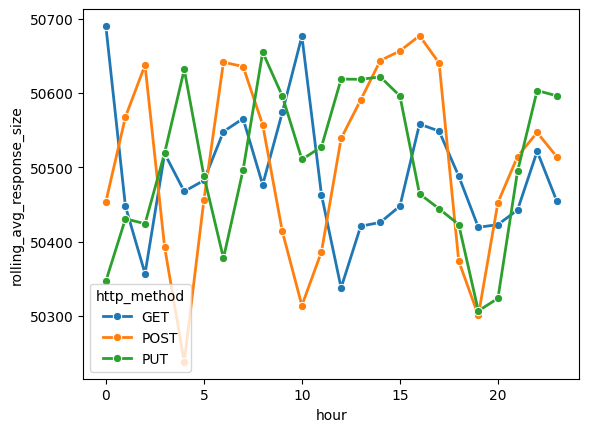

In [ ]:
# converting df to pandas for visualisation
rolling_avg_df = sqlDF1.toPandas()

# line chart using seaborn
sns.lineplot(
    data=rolling_avg_df,
    x='hour',
    y='rolling_avg_response_size',
    hue='http_method',
    marker='o',
    linewidth=2,
)

In [ ]:
# Advanced DF Analysis 2: HTTP Method Distribution and Response Size Statistics
# This query calculates the distribution of HTTP methods and provides statistics for the total and average response size for each HTTP method.

sqlDF2 = spark.sql('''
SELECT
    http_method,
    COUNT(*) AS total_requests,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS percentage_of_total_requests,
    SUM(response_size) AS total_response_size,
    AVG(response_size) AS average_response_size,
    MAX(response_size) AS max_response_size,
    MIN(response_size) AS min_response_size
FROM temp_log
GROUP BY http_method
ORDER BY total_requests DESC;
''')
sqlDF2.show()

24/12/15 17:02:21 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
24/12/15 17:02:21 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
24/12/15 17:02:21 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
24/12/15 17:02:24 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
24/12/15 17:02:24 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
24/12/15 17:02:24 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
24/12/15 1

+-----------+--------------+----------------------------+-------------------+---------------------+-----------------+-----------------+
|http_method|total_requests|percentage_of_total_requests|total_response_size|average_response_size|max_response_size|min_response_size|
+-----------+--------------+----------------------------+-------------------+---------------------+-----------------+-----------------+
|        GET|       1001043|                       33.37|        50534774103|    50482.12125053569|           100000|             1000|
|       POST|       1000505|                       33.35|        50531539123|     50506.0335760441|           100000|             1000|
|        PUT|        998452|                       33.28|        50431138942|    50509.32738078546|           100000|             1000|
+-----------+--------------+----------------------------+-------------------+---------------------+-----------------+-----------------+



24/12/15 17:02:24 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
24/12/15 17:02:24 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
24/12/15 17:02:28 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
24/12/15 17:02:28 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
24/12/15 17:02:28 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
24/12/15 17:02:28 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


<Axes: xlabel='http_method', ylabel='total_requests'>

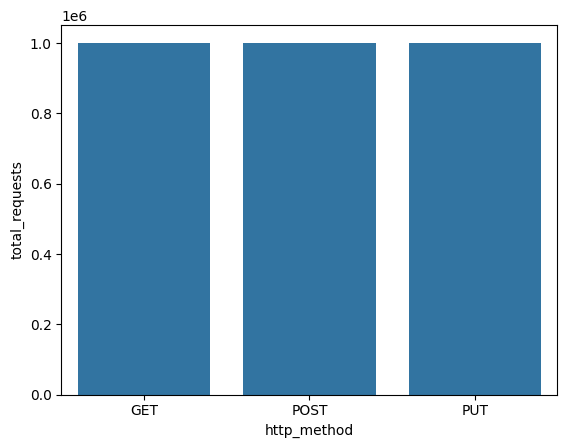

In [ ]:
http_method_stats = sqlDF2.toPandas()

# bar chart using seaborn
sns.barplot(data=http_method_stats, x='http_method', y='total_requests')

In [ ]:


log_rdd = spark.sparkContext.textFile(log_path)

# Define function to parse logs
def parse_log(line):
    import re
    match = re.match(log_pattern, line)
    if match:
        return (match.group(1), match.group(2), match.group(3), match.group(4), match.group(5), match.group(6), match.group(7), match.group(8))
    return None

parsed_logs = log_rdd.map(parse_log).filter(lambda x: x is not None)
parsed_logs.take(5)

[('88.211.105.115',
  '04/Mar/2022:14:17:48',
  'POST',
  '/history/missions/',
  'HTTP/2.0',
  '414',
  '12456',
  'Caution: System may require attention. Check logs for details.'),
 ('144.6.49.142',
  '02/Sep/2022:15:16:00',
  'POST',
  '/security/firewall/',
  'HTTPS/1.0',
  '203',
  '97126',
  'Warning: Unusual behavior detected. Investigate further.'),
 ('231.70.64.145',
  '19/Jul/2022:01:31:31',
  'PUT',
  '/web-development/countdown/',
  'HTTP/1.0',
  '201',
  '33093',
  'Informational message. No action required.'),
 ('219.42.234.172',
  '08/Feb/2022:11:34:57',
  'POST',
  '/networking/technology/',
  'HTTP/1.0',
  '415',
  '68827',
  'Debug: Detailed system state information.'),
 ('183.173.185.94',
  '29/Aug/2023:03:07:11',
  'GET',
  '/security/firewall/',
  'HTTP/2.0',
  '205',
  '30374',
  'Warning: Unusual behavior detected. Investigate further.')]

In [ ]:
# Count requests per IP
ip_requests = parsed_logs.map(lambda x: (x[0], 1)).reduceByKey(lambda a, b: a + b)
ip_requests.take(10)

[('123.31.25.147', 1),
 ('250.231.144.68', 1),
 ('87.51.27.172', 1),
 ('20.172.131.244', 1),
 ('248.182.198.107', 1),
 ('161.11.231.16', 1),
 ('79.16.33.140', 1),
 ('58.25.132.254', 1),
 ('213.110.110.210', 1),
 ('129.74.83.67', 1)]

In [ ]:
# Top 10 visited URLs
top_urls_rdd = parsed_logs.map(lambda x: (x[3], 1)).reduceByKey(lambda a, b: a + b).sortBy(lambda x: -x[1])
top_urls_rdd.take(10)

# Average response size per URL
response_size_per_url = parsed_logs.map(lambda x: (x[3], (int(x[6]), 1))) \
    .reduceByKey(lambda a, b: (a[0] + b[0], a[1] + b[1])) \
    .mapValues(lambda x: x[0] / x[1])
response_size_per_url.take(10)

[('/networking/technology/', 50427.44137792103),
 ('/web-development/technology/', 50433.43041812959),
 ('/shuttle/deep-learning/', 50642.04329731893),
 ('/web-development/firewall/', 50454.99935491674),
 ('/machine-learning/aws-certification/', 50434.33362792753),
 ('/data-analysis/cybersecurity/', 50485.06530904463),
 ('/machine-learning/cybersecurity/', 50580.990292430506),
 ('/cloud-computing/apollo/', 50704.82130391173),
 ('/shuttle/apollo-11/', 50895.58533466533),
 ('/machine-learning/technology/', 50376.24829203218)]

In [ ]:


# WORKING WITH RDD

import re
from pyspark import SparkContext

# REGEX PATTERN FOR PARSING
log_pattern = re.compile(
    r'(?P<ip>\d+\.\d+\.\d+\.\d+)\s+-\s+-\s+\[(?P<timestamp>.*?)\]\s+"(?P<http_method>\w+)\s+(?P<url>[^\s]+)\s+HTTP/\d+\.\d+"\s+(?P<status_code>\d+)\s+(?P<response_size>\d+)\s+(?P<message>.+)'
)

# CUSTOM PARSING FUNCTION WITH ERROR HANDLING
def parse_log(line):
    try:
        match = log_pattern.match(line)
        if match:
            return match.groupdict()  # THIS RETURNS FIELDS AS A DICTIONARY
        return None  # IGNORE UNPARSABLE LOGS
    except Exception as e:
        print(f"Error parsing line: {line}\nError: {e}")
        return None



In [ ]:
# INITIALIZE SPARK CONTEXT(Using Current Spark session)
sc = spark.sparkContext

# LOADING THE LOG DATA INTO RDD
log_data_path = log_path
log_rdd = sc.textFile(log_data_path)

# FILTERING TO PARSE LOGS
parsed_logs = log_rdd.map(parse_log).filter(lambda x: x is not None)

# VIEWING THE PARSED LOGS (First 20)
for log in parsed_logs.take(20):
         print(f"IP: {log['ip']:20} | URL: {log['url']:40} | Status Code: {log['status_code']:15} | Timestamp: {log['timestamp']:25} | Requests: {log['http_method']:20}")


IP: 88.211.105.115       | URL: /history/missions/                       | Status Code: 414             | Timestamp: 04/Mar/2022:14:17:48      | Requests: POST                
IP: 231.70.64.145        | URL: /web-development/countdown/              | Status Code: 201             | Timestamp: 19/Jul/2022:01:31:31      | Requests: PUT                 
IP: 219.42.234.172       | URL: /networking/technology/                  | Status Code: 415             | Timestamp: 08/Feb/2022:11:34:57      | Requests: POST                
IP: 183.173.185.94       | URL: /security/firewall/                      | Status Code: 205             | Timestamp: 29/Aug/2023:03:07:11      | Requests: GET                 
IP: 164.12.8.113         | URL: /web-development/technology/             | Status Code: 200             | Timestamp: 22/May/2023:09:48:25      | Requests: GET                 
IP: 110.98.7.240         | URL: /history/apollo/                         | Status Code: 204             | Timestamp: 22/

In [ ]:
# BASIC RDD TRANSFORMATIONS AND ACTIONS

# USE OF MAP FUNCTION
# WE CAN USE THE MAP FUNCTION TO LOOP THROUGH THE DATASET TO EXTRACT SPECIFIC FIELDS

# I WILL BE EXTRACTING URL, IP AND STATUS CODE
mapped_logs = parsed_logs.map(lambda log: (log['ip'], log['url'], log['status_code']))
first_20_logs = mapped_logs.take(20)

for log in first_20_logs:
    print(f"IP: {log[0]:<20} | URL: {log[1]:<40} | Status Code: {log[2]:<15}")


IP: 88.211.105.115       | URL: /history/missions/                       | Status Code: 414            
IP: 231.70.64.145        | URL: /web-development/countdown/              | Status Code: 201            
IP: 219.42.234.172       | URL: /networking/technology/                  | Status Code: 415            
IP: 183.173.185.94       | URL: /security/firewall/                      | Status Code: 205            
IP: 164.12.8.113         | URL: /web-development/technology/             | Status Code: 200            
IP: 110.98.7.240         | URL: /history/apollo/                         | Status Code: 204            
IP: 123.31.25.147        | URL: /data-analysis/missions/                 | Status Code: 204            
IP: 220.182.78.75        | URL: /history/launch/                         | Status Code: 200            
IP: 206.186.128.82       | URL: /security/apollo-11/                     | Status Code: 404            
IP: 12.33.251.59         | URL: /web-development/data/          

In [ ]:
# FLAT MAP

# WE CAN USE FLAT MAP TO SPLIT AND COUNT THE FREQUENCY OF A GIVEN FIELD (UNIQUE HTTP METHOD)

http_methods = parsed_logs.flatMap(lambda log: [log['http_method']])
method_counts = http_methods.map(lambda method: (method, 1)).reduceByKey(lambda a, b: a + b)
method_counts.collect()


[('POST', 666715), ('GET', 667609), ('PUT', 666328)]

In [ ]:
# FILTER

# THIS LOOPS THROUGH THE DATASET AND FILTERS GIVEN FIELDS WHICH CONDITIONS WERE MET

error_logs = parsed_logs.filter(lambda log: int(log['status_code']) >= 400)

# TO SHOW ONLY FIRST 20 ERRORS
error_sample = error_logs.take(20)

for log in error_sample:
       print(f"IP: {log['ip']:<20} | Timestamp: {log['timestamp']:<40} | Status Code: {log['status_code']:<15} | Message: {log['message']:<30}")


IP: 88.211.105.115       | Timestamp: 04/Mar/2022:14:17:48                     | Status Code: 414             | Message: Caution: System may require attention. Check logs for details.
IP: 219.42.234.172       | Timestamp: 08/Feb/2022:11:34:57                     | Status Code: 415             | Message: Debug: Detailed system state information.
IP: 206.186.128.82       | Timestamp: 13/Oct/2023:07:21:13                     | Status Code: 404             | Message: Debugging information. For developer reference only.
IP: 103.105.160.60       | Timestamp: 24/Oct/2023:01:54:56                     | Status Code: 416             | Message: Warning: Unusual behavior detected. Investigate further.
IP: 246.167.148.159      | Timestamp: 14/Oct/2022:11:49:35                     | Status Code: 500             | Message: Debug: Detailed system state information.
IP: 87.51.27.172         | Timestamp: 24/Mar/2023:08:17:52                     | Status Code: 404             | Message: Potential issue d

In [ ]:
# REDUCE

# THIS RETURNS THE TOTAL SIZE OF A GIVEN FIELD IN THE DATASET(RESPONSE SIZE)

total_response_size = parsed_logs.map(lambda log: int(log['response_size'])).reduce(lambda a, b: a + b)
total_response_size


101030259486

In [ ]:
# ADVANCED RDD QUERIES USING ALREADY PARSED LOGS

# CALCULATING THE TOP 10 MOST VISITED SITES(QUERY 1)
top_urls = (
    parsed_logs.map(lambda log: (log['url'], 1))
    .reduceByKey(lambda a, b: a + b)
    .sortByKey(False)  # Sort descending by visit counts
    .take(10)
)

top_urls_result = top_urls

print("\nTop 10 Visited URLs:")
for url, count in top_urls_result:
    print(f"{url}: {count}")


Top 10 Visited URLs:
/web-development/technology/: 16676
/web-development/missions/: 16946
/web-development/launch/: 16677
/web-development/frontend-frameworks-comparison/: 16595
/web-development/firewall/: 16559
/web-development/deep-learning/: 16780
/web-development/data/: 16810
/web-development/cybersecurity/: 16505
/web-development/countdown/: 16491
/web-development/aws-certification/: 16312


In [ ]:
# CALCULATING AVERAGE RESPONSE SIZE(QUERY 2)

response_size_per_url = parsed_logs.map(lambda log: (log["url"], (int(log["response_size"]), 1))) \
    .reduceByKey(lambda a, b: (a[0] + b[0], a[1] + b[1])) \
    .mapValues(lambda x: x[0] / x[1]) \
    .sortByKey()

# USING (int(log["response_size"]) ENSURES THAT RESPONSE SIZES ARE TREATED AS INTEGERS, THUS
# ALLOWING THE DIVISION TO BE PERFORMED CORRECTLY USING MAPVALUES FUNCTION.

response_size_per_url.take(10)

[('/cloud-computing/apollo-11/', 50459.44408109876),
 ('/cloud-computing/apollo/', 50625.44117293594),
 ('/cloud-computing/aws-certification/', 50331.1429756965),
 ('/cloud-computing/countdown/', 50599.1864640884),
 ('/cloud-computing/cybersecurity/', 50666.965290638625),
 ('/cloud-computing/data/', 50273.61065302438),
 ('/cloud-computing/deep-learning/', 50756.058247108944),
 ('/cloud-computing/firewall/', 50966.29082090893),
 ('/cloud-computing/frontend-frameworks-comparison/', 50275.78460328028),
 ('/cloud-computing/launch/', 50551.13271586495)]

In [ ]:

log_data=sc.textFile(log_path)

def parse_log_entries(log):
  #regular expression
  log_pattern=r'^([^\ ]*) - - \[([^\]]*)\] "([A-Z]+) ([^\ ]*) ([^\ ]*)" (\d+) (\d+) (.*)$'
  match=re.match(log_pattern,log)

  if match:
    try:
      ip=match.group(1)
      date=match.group(2)
      method=match.group(3)
      url=match.group(4)
      http_version=match.group(5)
      status_code=int(match.group(6))
      bytes_=int(match.group(7))
      message=match.group(8).strip()

      return(ip,date,method,url,http_version,status_code,bytes_,message)
    except Exception as e:
      return None
  else:
    return None

#extract the entries
parsed_log_entries=log_data.map(parse_log_entries).filter(lambda x:x is not None)

print(parsed_log_entries.take(1))

[('88.211.105.115', '04/Mar/2022:14:17:48', 'POST', '/history/missions/', 'HTTP/2.0', 414, 12456, 'Caution: System may require attention. Check logs for details.')]


In [ ]:
#one basic RDD transformation+action operator
#printing all the failed requests in the log data
failed_req=parsed_log_entries.filter(lambda x:x[5]>=400 and x[5]<600).map(lambda x:(x[5],1)).reduceByKey(lambda a,b:a+b).collect()
print(failed_req)

[(416, 214174), (404, 214584), (500, 214527), (414, 214705), (415, 214135)]


In [ ]:
#advanced RDD analysis 1:
#identifying the number of times a URL returning large data(over 10000BYTES)
#filtering data over 1mb
large_data=parsed_log_entries.filter(lambda x:x[6]>10000)

large_data_urls=large_data.map(lambda x:(x[3],1)).reduceByKey(lambda a,b:a+b).sortBy(lambda x:x[1],ascending=False).collect()
for url,count in large_data_urls:
  print(f'URL: {url},:{count}times')

URL: /data-analysis/apollo/,:23106times
URL: /security/technology/,:23053times
URL: /software/data/,:23047times
URL: /web-development/missions/,:23047times
URL: /history/countdown/,:23032times
URL: /history/apollo/,:22998times
URL: /networking/deep-learning/,:22984times
URL: /machine-learning/countdown/,:22983times
URL: /history/technology/,:22947times
URL: /networking/frontend-frameworks-comparison/,:22944times
URL: /security/countdown/,:22923times
URL: /web-development/deep-learning/,:22919times
URL: /data-analysis/frontend-frameworks-comparison/,:22917times
URL: /images/apollo/,:22916times
URL: /images/apollo-11/,:22916times
URL: /web-development/apollo-11/,:22916times
URL: /networking/firewall/,:22910times
URL: /history/missions/,:22902times
URL: /software/technology/,:22895times
URL: /history/deep-learning/,:22891times
URL: /history/data/,:22887times
URL: /web-development/data/,:22884times
URL: /data-analysis/cybersecurity/,:22873times
URL: /security/deep-learning/,:22867times
URL

In [ ]:
#advanced RDD analysis 2:
#Count the number of requests per protocol version
protocol_count=parsed_log_entries.map(lambda x:(x[4],1)).reduceByKey(lambda a,b:a+b).sortBy(lambda x:x[1],ascending=False).collect()
print(protocol_count)

[('HTTP/2.0', 1000568), ('HTTP/1.0', 1000084), ('HTTPS/1.0', 999348)]


In [ ]:


# initializing rdd
rdd = sc.textFile(log_path)

def parse_log_data(line):
    log_pattern = r'(\d+\.\d+\.\d+\.\d+) - - \[(.*?)\] "(.*?) (.*?) (.*?)" (\d{3}) (\d+) (.*)'
    match = re.match(log_pattern, line)
    if match:
        groups = match.groups()
        timestamp = groups[1]  # Timestamp
        http_method = groups[2]  # HTTP method
        try:
            response_size = int(groups[6])  # Response size
        except ValueError:
            response_size = 0  # Handle malformed response sizes
        return (timestamp, http_method, response_size)
    return None


# Parse RDD using the custom function
parsed_rdd = rdd.map(parse_log_data).filter(lambda x: x is not None)
non_parsed_rdd = rdd.map(parse_log_data).filter(lambda x: x is None)

print(f"Parsed records: {parsed_rdd.count()}")
print(f"Non-parsed records: {non_parsed_rdd.count()}")

Parsed records: 3000000


Non-parsed records: 0


In [ ]:
# Basic RDD 1
# Calculate total response size

total_response_size = parsed_rdd.map(lambda x: x[2]).reduce(lambda x, y: x + y)
print("Total response size:", total_response_size, "bytes")

Total response size: 151497452168 bytes


In [ ]:
# Advanced RDD Analysis 1: Calculate Hourly Total Response Size Per HTTP Method

# Map to (hour, http_method), response_size
hourly_rdd = parsed_rdd.map(lambda x: ((x[0][12:14], x[1]), x[2]))

# Aggregate response sizes by hour, http_method
hourly_total_response = hourly_rdd.reduceByKey(lambda x, y: x + y)

# Sort by hour
sorted_hourly_response = hourly_total_response.sortByKey()

for key, value in sorted_hourly_response.collect():
    print(f"Hour: {key[0]}, HTTP Method: {key[1]}, Total Response Size: {value}")

Hour: 00, HTTP Method: GET, Total Response Size: 2126857628
Hour: 00, HTTP Method: POST, Total Response Size: 2102446711
Hour: 00, HTTP Method: PUT, Total Response Size: 2101675260
Hour: 01, HTTP Method: GET, Total Response Size: 2091721272
Hour: 01, HTTP Method: POST, Total Response Size: 2113155010
Hour: 01, HTTP Method: PUT, Total Response Size: 2097702850
Hour: 02, HTTP Method: GET, Total Response Size: 2101120798
Hour: 02, HTTP Method: POST, Total Response Size: 2100493353
Hour: 02, HTTP Method: PUT, Total Response Size: 2108160708
Hour: 03, HTTP Method: GET, Total Response Size: 2111197729
Hour: 03, HTTP Method: POST, Total Response Size: 2085447101
Hour: 03, HTTP Method: PUT, Total Response Size: 2110047984
Hour: 04, HTTP Method: GET, Total Response Size: 2097807975
Hour: 04, HTTP Method: POST, Total Response Size: 2106344190
Hour: 04, HTTP Method: PUT, Total Response Size: 2109988147
Hour: 05, HTTP Method: GET, Total Response Size: 2102213631
Hour: 05, HTTP Method: POST, Total 

In [ ]:
# Advanced RDD Analysis 2: Hour with maximum traffic count and response size for each http method

# Map to http_method, (hour, response_size)
hourly_rdd = parsed_rdd.map(lambda x: (x[1], (x[0][12:14], x[2])))

# Group by http_method
grouped_by_method = hourly_rdd.groupByKey()

# hour with maximum traffic for each HTTP method
max_traffic_hour = grouped_by_method.mapValues(
    lambda hour_data: max(hour_data, key=lambda x: x[1])  # Find hour with max response size
)

for key, value in max_traffic_hour.collect():
    print(f"HTTP Method: {key}, Hour with Maximum Traffic: {value[0]}, Response Size: {value[1]}")

HTTP Method: POST, Hour with Maximum Traffic: 20, Response Size: 100000
HTTP Method: GET, Hour with Maximum Traffic: 16, Response Size: 100000
HTTP Method: PUT, Hour with Maximum Traffic: 10, Response Size: 100000


In [ ]:

%%time
logs_df.count()

CPU times: user 5.52 ms, sys: 3.26 ms, total: 8.78 ms
Wall time: 18.1 s


3000000

In [ ]:
%%time
logs_df.cache()
logs_df.count()

CPU times: user 15 ms, sys: 8.65 ms, total: 23.7 ms
Wall time: 1min 41s


3000000

In [ ]:
%%time

logs_df.count()

CPU times: user 790 μs, sys: 1.09 ms, total: 1.88 ms
Wall time: 66.3 ms


3000000

In [ ]:
logs_df.write.bucketBy(10, "url").sortBy("http_method").saveAsTable("P_Version")

24/12/15 17:55:45 WARN MemoryManager: Total allocation exceeds 95.00% (913,965,045 bytes) of heap memory
Scaling row group sizes to 97.28% for 7 writers
24/12/15 17:55:45 WARN MemoryManager: Total allocation exceeds 95.00% (913,965,045 bytes) of heap memory
Scaling row group sizes to 85.12% for 8 writers
24/12/15 17:55:50 WARN MemoryManager: Total allocation exceeds 95.00% (913,965,045 bytes) of heap memory
Scaling row group sizes to 97.28% for 7 writers
24/12/15 17:55:50 WARN MemoryManager: Total allocation exceeds 95.00% (913,965,045 bytes) of heap memory
Scaling row group sizes to 97.28% for 7 writers
24/12/15 17:55:50 WARN MemoryManager: Total allocation exceeds 95.00% (913,965,045 bytes) of heap memory
Scaling row group sizes to 85.12% for 8 writers
24/12/15 17:55:50 WARN MemoryManager: Total allocation exceeds 95.00% (913,965,045 bytes) of heap memory
Scaling row group sizes to 97.28% for 7 writers
24/12/15 17:55:51 WARN MemoryManager: Total allocation exceeds 95.00% (913,965,045

In [ ]:
%%time
logs_df.count()

CPU times: user 752 μs, sys: 1.02 ms, total: 1.78 ms
Wall time: 63.9 ms


3000000

In [ ]:

# CACHING / NON CACHING USING DF

# WITHOUT CACHING
%%time
group_counts = parsed_df.groupBy("method").count().collect()
group_counts

CPU times: user 4.36 ms, sys: 2.62 ms, total: 6.98 ms
Wall time: 1.05 s


[Row(method='POST', count=1000505),
 Row(method='PUT', count=998452),
 Row(method='GET', count=1001043)]

In [ ]:
# WITH CACHING
%%time
from pyspark import StorageLevel

# CACHING THE DATAFRAME
parsed_df.persist(StorageLevel.MEMORY_ONLY)

# PERFORMING THE SAME OPERATION ON THE CACHED DF
cached_group_counts = parsed_df.groupBy("method").count().collect()
cached_group_counts

24/12/15 17:21:45 WARN CacheManager: Asked to cache already cached data.


CPU times: user 3.43 ms, sys: 2 ms, total: 5.42 ms
Wall time: 1.56 s


[Row(method='POST', count=1000505),
 Row(method='PUT', count=998452),
 Row(method='GET', count=1001043)]

In [ ]:
# DIFFERENT PARTITION STRATEGIES USING RDD

# DEFAULT PARTITIONING
%%time
default_partitioned_rdd = parsed_logs.map(lambda log: (log['http_method'], log['response_size'])) \
                                   .reduceByKey(lambda a, b: a + b)

# PERFORMING AN ACTION TO MEASURE EXECUTION TIME
default_partitioned_rdd.collect()

num_partitions = default_partitioned_rdd.getNumPartitions()
print(f"Number of partitions: {num_partitions}")

Number of partitions: 13
CPU times: user 12.8 ms, sys: 8.96 ms, total: 21.8 ms
Wall time: 5.68 s


In [ ]:
# RE-PARTITIONING
%%time
repartitioned_rdd = parsed_logs.repartition(5) \
                               .map(lambda log: (log['http_method'], int(log['response_size']))) \
                               .reduceByKey(lambda a, b: a + b)

repartitioned_rdd.collect()

num_partitions = repartitioned_rdd.getNumPartitions()
print(f"Number of partitions after repartitioning: {num_partitions}")

Number of partitions after repartitioning: 5
CPU times: user 12 ms, sys: 5.23 ms, total: 17.2 ms
Wall time: 3.94 s


In [ ]:
# COMPARING PERFORMANCE WHEN EXECUTING TRANSFORMATIONS
%%time
# CREATING A PAIR RDD (http_method, log)
keyed_rdd = parsed_logs.map(lambda log: (log['http_method'], log))

# PARTITION BY KEY (USING PARTITIONBY)
partitioned_by_key_rdd = keyed_rdd.partitionBy(5)  # USING 5 PARTITIONS

# USING REDUCEBYKEY OPERATION
result_rdd = partitioned_by_key_rdd.map(lambda x: (x[0], x[1]['response_size'])) \
                                 .reduceByKey(lambda a, b: a + b)

result_rdd.collect()

num_partitions = result_rdd.getNumPartitions()
print(f"Number of partitions after partitioning by key: {num_partitions}")

Number of partitions after partitioning by key: 5
CPU times: user 23 ms, sys: 11.9 ms, total: 34.9 ms
Wall time: 1min 42s


In [ ]:

#1st strategy- Partitioning
#before partition-Traffic patterns with daily unique visitors
%%time
sqldf=spark.sql('''
SELECT
  date_format(date,'yyyy-MM-dd') As Day,
  COUNT(DISTINCT ip) AS unique_visitors,
  COUNT(*) AS total_requests
FROM weblogview
GROUP BY date_format(date,'yyyy-MM-dd')
ORDER BY Day
''')


CPU times: user 1.27 ms, sys: 1.51 ms, total: 2.78 ms
Wall time: 14.6 ms


In [ ]:
#after partitioning-Traffic patterns with daily unique visitors
%%time

from pyspark.sql.functions import hour

#partitioning the date into 4 partitions
repartitioned_df = new_df.withColumn('Day', date_format(new_df['date'],'yyyy-MM-dd')).repartition(4, 'Day')

#sql query execution after repartition
repartitioned_df.createOrReplaceTempView('weblogview_partitioned')

sqldf_partitioned = sqldf=spark.sql('''
SELECT
  date_format(date,'yyyy-MM-dd') As Day,
  COUNT(DISTINCT ip) AS unique_visitors,
  COUNT(*) AS total_requests
FROM weblogview
GROUP BY date_format(date,'yyyy-MM-dd')
ORDER BY Day
''')
sqldf_partitioned.show()

24/12/15 17:10:19 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
24/12/15 17:10:19 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
24/12/15 17:10:19 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
24/12/15 17:10:19 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
24/12/15 17:10:19 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
24/12/15 17:10:19 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
24/12/15 17:10:19 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
24/12/15 17:10:20 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
24/12/15 17:10:25 WARN RowBasedKeyValueBatch: Calling spill() on

+----------+---------------+--------------+
|       Day|unique_visitors|total_requests|
+----------+---------------+--------------+
|2022-01-01|           4533|          4533|
|2022-01-02|           4351|          4351|
|2022-01-03|           4331|          4331|
|2022-01-04|           4383|          4383|
|2022-01-05|           4464|          4464|
|2022-01-06|           4418|          4418|
|2022-01-07|           4384|          4384|
|2022-01-08|           4298|          4298|
|2022-01-09|           4365|          4365|
|2022-01-10|           4394|          4395|
|2022-01-11|           4405|          4405|
|2022-01-12|           4365|          4365|
|2022-01-13|           4345|          4345|
|2022-01-14|           4385|          4385|
|2022-01-15|           4400|          4400|
|2022-01-16|           4412|          4412|
|2022-01-17|           4344|          4344|
|2022-01-18|           4511|          4511|
|2022-01-19|           4357|          4357|
|2022-01-20|           4393|    

In [ ]:
#2nd Strategy- Caching
#without caching-detecting traffic spikes with rolling hourly requests
%%time
sqldf = spark.sql('''
SELECT
    hour(date) AS hour,
    COUNT(*) AS requests,
    SUM(COUNT(*)) OVER (ORDER BY hour(date) ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) AS rolling_hourly_requests
FROM weblogview
GROUP BY hour(date)
ORDER BY hour LIMIT 10
''')
sqldf.show()

24/12/15 17:10:29 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
24/12/15 17:10:29 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
24/12/15 17:10:29 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


+----+--------+-----------------------+
|hour|requests|rolling_hourly_requests|
+----+--------+-----------------------+
|   0|  125373|                 125373|
|   1|  124493|                 249866|
|   2|  125392|                 375258|
|   3|  124947|                 500205|
|   4|  125239|                 625444|
|   5|  125049|                 750493|
|   6|  125200|                 875693|
|   7|  124930|                1000623|
|   8|  124976|                1125599|
|   9|  125056|                1250655|
+----+--------+-----------------------+

CPU times: user 3.51 ms, sys: 2.17 ms, total: 5.68 ms
Wall time: 7.34 s


24/12/15 17:10:36 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
24/12/15 17:10:36 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
24/12/15 17:10:36 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
24/12/15 17:10:36 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


In [ ]:
%%time
#after caching-detecting traffic spikes with rolling hourly requests
new_df.persist(StorageLevel.MEMORY_AND_DISK)
new_df.createOrReplaceTempView('weblogview')
cached_df = spark.sql('''
SELECT
    hour(date) AS hour,
    COUNT(*) AS requests,
    SUM(COUNT(*)) OVER (ORDER BY hour(date) ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) AS rolling_hourly_requests
FROM weblogview
GROUP BY hour(date)
ORDER BY hour LIMIT 10
''')
cached_df.show()

24/12/15 17:11:04 WARN CacheManager: Asked to cache already cached data.
24/12/15 17:11:04 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
24/12/15 17:11:04 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
24/12/15 17:11:04 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
24/12/15 17:11:23 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
24/12/15 17:11:23 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


+----+--------+-----------------------+
|hour|requests|rolling_hourly_requests|
+----+--------+-----------------------+
|   0|  125373|                 125373|
|   1|  124493|                 249866|
|   2|  125392|                 375258|
|   3|  124947|                 500205|
|   4|  125239|                 625444|
|   5|  125049|                 750493|
|   6|  125200|                 875693|
|   7|  124930|                1000623|
|   8|  124976|                1125599|
|   9|  125056|                1250655|
+----+--------+-----------------------+

CPU times: user 8.56 ms, sys: 5.5 ms, total: 14.1 ms
Wall time: 20.7 s


24/12/15 17:11:24 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
24/12/15 17:11:24 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
24/12/15 17:11:24 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
24/12/15 17:11:24 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


In [ ]:
#faster as data is cached now
%%time
cached_df.show()

24/12/15 17:11:24 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
24/12/15 17:11:24 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
24/12/15 17:11:24 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
24/12/15 17:11:24 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
24/12/15 17:11:24 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


+----+--------+-----------------------+
|hour|requests|rolling_hourly_requests|
+----+--------+-----------------------+
|   0|  125373|                 125373|
|   1|  124493|                 249866|
|   2|  125392|                 375258|
|   3|  124947|                 500205|
|   4|  125239|                 625444|
|   5|  125049|                 750493|
|   6|  125200|                 875693|
|   7|  124930|                1000623|
|   8|  124976|                1125599|
|   9|  125056|                1250655|
+----+--------+-----------------------+

CPU times: user 3.83 ms, sys: 2.69 ms, total: 6.52 ms
Wall time: 1.89 s


24/12/15 17:11:26 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
24/12/15 17:11:26 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
24/12/15 17:11:26 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
24/12/15 17:11:26 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


In [ ]:

# Different partition strategy
# non-partitioned result on df

%%time

not_partitioned_df = df.groupBy('http_method').agg({'response_size': 'sum'})
not_partitioned_df.show()

+-----------+------------------+
|http_method|sum(response_size)|
+-----------+------------------+
|       POST|       50531539123|
|        PUT|       50431138942|
|        GET|       50534774103|
+-----------+------------------+

CPU times: user 3.56 ms, sys: 2.22 ms, total: 5.78 ms
Wall time: 2.78 s


In [ ]:
num_partitions = not_partitioned_df.rdd.getNumPartitions()
print(f"Number of partitions: {num_partitions}")

df_repartitioned = df.repartition(4)

num_partitions = df_repartitioned.rdd.getNumPartitions()
print(f"Number of partitions after repartitioning: {num_partitions}")

Number of partitions: 1


Number of partitions after repartitioning: 4


In [ ]:
# partitioned result on df
%%time

repartitioned_df = df_repartitioned.groupBy('http_method').agg({'response_size': 'sum'})
repartitioned_df.show()

+-----------+------------------+
|http_method|sum(response_size)|
+-----------+------------------+
|       POST|       50531539123|
|        PUT|       50431138942|
|        GET|       50534774103|
+-----------+------------------+

CPU times: user 2.33 ms, sys: 1.87 ms, total: 4.2 ms
Wall time: 1.27 s


In [ ]:
# non-cached result on df

%%time

group_counts = df.groupBy("http_method").count().collect()
group_counts

CPU times: user 2.16 ms, sys: 1.94 ms, total: 4.1 ms
Wall time: 462 ms


[Row(http_method='POST', count=1000505),
 Row(http_method='PUT', count=998452),
 Row(http_method='GET', count=1001043)]

In [ ]:
from pyspark import StorageLevel

df.persist(StorageLevel.MEMORY_ONLY)

DataFrame[timestamp: timestamp, http_method: string, response_size: int]

In [ ]:
# cached result on df

%%time

cached_group_counts = df.groupBy("http_method").count().collect()
cached_group_counts

CPU times: user 2.52 ms, sys: 2.01 ms, total: 4.53 ms
Wall time: 296 ms


[Row(http_method='POST', count=1000505),
 Row(http_method='PUT', count=998452),
 Row(http_method='GET', count=1001043)]